# Assignment 2 — AcnEmpathize: Prompting

**Course:** Natural Language Processing  
**Group:** 12

    Guilherme Oliveira: 202204987
    Magda Costa: 202207036

---

# Index

1. [Motivation](#motivation)
2. [Setup](#setup)
3. [Prompt Design](#prompts)
4. [Run Prompting Experiments](#run)
5. [Results and Comparison](#results)
6. [Conclusions](#conclusions)

---
# 1. Motivation <a name="motivation"></a>

### Where we are

Across notebooks 6, 7, and 8 we built a complete supervised learning story for AcnEmpathize:

| Model | Macro-F1 | Emp-F1 | Trainable Params | Time |
|---|---|---|---|---|
| LR + TF-IDF trigrams (A1) | 0.761 | 0.637 | ~5k | <1 min |
| RoBERTa-base (full FT) | 0.888 | 0.829 | ~125M | 118 min |
| RoBERTa-TAPT (full FT) | 0.891 | 0.836 | ~125M | ~180 min |
| LoRA RoBERTa-TAPT | 0.887 | 0.832 | 887k (0.71%) | 110 min |
| **LoRA RoBERTa-base** | **0.898** | **0.849** | **887k (0.71%)** | **89 min** |

Every model in this table required labelled training data. The best result (LoRA, Macro-F1=0.898) was achieved by training on 7,774 labelled posts. But what if we had **no labelled data at all?**

This is the question prompting addresses — and it is fundamentally different from everything we have done so far. Prompting is not another point on the efficiency/performance tradeoff curve. It is a **different paradigm entirely**: instead of learning from examples, we directly operationalise the annotation guidelines as a natural language instruction and ask a pre-trained language model to apply them.

---

### Why this is motivated by our own results

The annotation framework for AcnEmpathize (Lee & Parde 2024, adapted from Sharma et al. 2020) is explicit and precise. A post contains empathy if it satisfies **at least one** of:

1. **Emotional Reaction** — expresses warmth, compassion, or concern towards the seeker
2. **Interpretation** — communicates understanding of the seeker's experiences and feelings
3. **Exploration** — attempts to explore the seeker's experiences and feelings

And it is **not** empathy if it contains only:
- Advice or factual information
- Kindness or support without overt emotional understanding (*"good luck"*, *"I wish the best for you"*)
- Self-focused positivity (*"I'm so glad the cysts are gone!"*)
- Statements requiring assumptions about a different post

This framework is precise enough to be given directly to an instruction-tuned language model. The question is whether a model can apply these guidelines **without seeing a single labelled example**.

Two of our most consistent findings across A1 and A2 make this particularly interesting:

**Finding 1 — False positives are the main error type in both classical and transformer models.** Supportive and advice-heavy posts with warm tone are systematically mistaken for empathy. This is exactly the boundary the annotation guidelines draw most carefully — the distinction between kindness/support and genuine empathy. Prompting with explicit hard-negative examples targeting this boundary is theoretically the most direct way to address it.

**Finding 2 — The empathy signal is strongly lexical.** A1 showed that words like *"know"*, *"feel"*, *"sorry"*, *"relate"*, *"understand"* are the top discriminative features. An instruction-tuned LLM likely already associates these with empathy — but it may also associate *"good luck"* and *"hang in there"* with empathy, which violates the annotation framework.

---

### What we test and why

We test two prompting conditions, motivated directly by the above:

**Condition 1 — Zero-shot:** The annotation guidelines only, no examples. Tests whether the LLM can apply the three-mechanism framework directly from the instruction.

**Condition 2 — Few-shot with hard negatives:** Guidelines plus 3 empathy examples and 3 non-empathy examples, where the non-empathy examples are specifically chosen to be *advice-only* and *kindness-only* posts — the exact false-positive error type identified in A1 and confirmed in A2. This condition is the most theoretically motivated: it directly targets the systematic error that all our supervised models share.

We do **not** test a plain few-shot condition without hard negatives, because balanced random examples would not address the specific failure mode. Every prompting choice is grounded in what we already know.

---

### Scope and evaluation

Prompting with a large instruction model is slow. We evaluate on a **stratified sample of 200 posts** from the Split B test set (preserving the 24%/76% empathy/no-empathy ratio). This is sufficient to estimate Macro-F1 and empathy F1 reliably, and is standard practice for prompting evaluations where inference cost is high.

We use `mistralai/Mistral-7B-Instruct-v0.2` via the HuggingFace Inference API — a strong open instruction-tuned model that follows structured prompts reliably and is accessible without local GPU requirements.

---

### References
- Lee & Parde (2024). *AcnEmpathize: A Dataset for Understanding Empathy in Dermatology Conversations.* LREC-COLING.
- Sharma et al. (2020). *A Computational Approach to Understanding Empathy Expressed in Text-Based Mental Health Support.* EMNLP.
- Brown et al. (2020). *Language Models are Few-Shot Learners.* NeurIPS.
- Jiang et al. (2023). *Mistral 7B.* arXiv:2310.06825.

---
# 2. Setup <a name="setup"></a>

In [ ]:
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from huggingface_hub import InferenceClient
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score, confusion_matrix,
)

warnings.filterwarnings("ignore")

SEED      = 42
np.random.seed(SEED)

# ── Paths and constants ───────────────────────────────────────────────────────
TEXT_COL  = "text"
LABEL_COL = "combined_empathy"
CONV_COL  = "conv_id"
OUTPUT_DIR = Path("results/prompting")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── HuggingFace Inference API ─────────────────────────────────────────────────
# Set your HuggingFace token as an environment variable before running:
#   export HF_TOKEN="hf_..."
import os
HF_TOKEN  = os.environ.get("HF_TOKEN", "")
MODEL_ID  = "HuggingFaceH4/zephyr-7b-beta"

client = InferenceClient(model=MODEL_ID, token=HF_TOKEN)
print(f"Inference client ready. Model: {MODEL_ID}")

In [8]:
# ── Load dataset ──────────────────────────────────────────────────────────────
for path in ["AcnEmpathize_dataset.csv", "../AcnEmpathize_dataset.csv", "data/AcnEmpathize_dataset.csv"]:
    if Path(path).exists():
        df_raw = pd.read_csv(path)
        print(f"Loaded: {path}  |  Shape: {df_raw.shape}")
        break

df = df_raw[[TEXT_COL, LABEL_COL, CONV_COL]].copy()
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df[LABEL_COL] = df[LABEL_COL].astype(int)

def minimal_clean(text):
    if not isinstance(text, str): return ""
    return re.sub(r"\s+", " ", text.strip())

df["text_clean"] = df[TEXT_COL].apply(minimal_clean)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)

# ── Split B — identical to all previous notebooks ────────────────────────────
def make_group_split(df, group_col, seed=SEED):
    groups = df[group_col].unique()
    np.random.seed(seed)
    np.random.shuffle(groups)
    n = len(groups)
    n_te, n_va = int(np.ceil(n * 0.20)), int(np.ceil(n * 0.16))
    te_g = set(groups[:n_te])
    va_g = set(groups[n_te:n_te + n_va])
    tr_g = set(groups[n_te + n_va:])
    return (df[df[group_col].isin(tr_g)].reset_index(drop=True),
            df[df[group_col].isin(va_g)].reset_index(drop=True),
            df[df[group_col].isin(te_g)].reset_index(drop=True))

_, _, test_df = make_group_split(df, CONV_COL)
print(f"Test set: {len(test_df)} posts  |  Empathy rate: {test_df[LABEL_COL].mean():.1%}")

Loaded: AcnEmpathize_dataset.csv  |  Shape: (12212, 13)
Test set: 2477 posts  |  Empathy rate: 25.6%


In [9]:
# ── Stratified sample of 200 posts from test set ─────────────────────────────
# Preserves the natural 24%/76% empathy/no-empathy ratio.
# 200 posts is sufficient for reliable Macro-F1 estimation at reasonable API cost.
sample_df, _ = train_test_split(
    test_df,
    train_size=200,
    stratify=test_df[LABEL_COL],
    random_state=SEED
)
sample_df = sample_df.reset_index(drop=True)

print(f"Evaluation sample: {len(sample_df)} posts")
print(f"  Empathy:    {sample_df[LABEL_COL].sum()} ({sample_df[LABEL_COL].mean():.1%})")
print(f"  No empathy: {(sample_df[LABEL_COL]==0).sum()} ({(sample_df[LABEL_COL]==0).mean():.1%})")

Evaluation sample: 200 posts
  Empathy:    51 (25.5%)
  No empathy: 149 (74.5%)


In [10]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def full_metrics(y_true, y_pred):
    return {
        "accuracy":          accuracy_score(y_true, y_pred),
        "macro_f1":          f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_empathy": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_empathy":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_empathy":        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

# ── Inference helper ──────────────────────────────────────────────────────────
def parse_label(response_text):
    """Extract 0 or 1 from model JSON response. Returns -1 if parsing fails."""
    try:
        # Try to find JSON block
        match = re.search(r'\{.*?\}', response_text, re.DOTALL)
        if match:
            obj = json.loads(match.group())
            label = int(obj.get("label", -1))
            if label in [0, 1]:
                return label
    except Exception:
        pass
    # Fallback: scan for explicit 0 or 1
    if re.search(r'\blabel["\s]*:["\s]*1\b', response_text):
        return 1
    if re.search(r'\blabel["\s]*:["\s]*0\b', response_text):
        return 0
    return -1  # failed to parse


def run_prompting(prompt_fn, sample_df, condition_name, delay=0.5):
    """
    Run a prompting condition over the sample.
    prompt_fn: callable(post_text) -> str  (returns the full prompt)
    Returns a DataFrame with predictions and raw responses.
    """
    results = []
    failed  = 0
    for i, row in sample_df.iterrows():
        prompt = prompt_fn(row["text_clean"])
        try:
            response = client.text_generation(
                prompt,
                max_new_tokens=64,
                temperature=0.01,   # Near-deterministic; prompting is not generation
                do_sample=False,
            )
            label = parse_label(response)
        except Exception as e:
            response = str(e)
            label    = -1

        if label == -1:
            failed += 1

        results.append({
            "idx":       i,
            "true_label":row[LABEL_COL],
            "pred_label":label,
            "response":  response,
            "condition": condition_name,
        })

        if (len(results) % 20) == 0:
            print(f"  {len(results)}/{len(sample_df)} done  |  failed so far: {failed}")
        time.sleep(delay)  # Rate limiting

    df_out = pd.DataFrame(results)
    print(f"Done. Total failed parses: {failed}/{len(sample_df)}")
    return df_out

print("Helpers defined.")

Helpers defined.


---
# 3. Prompt Design <a name="prompts"></a>

### Design principles

Both prompts share the same core structure:
1. The annotation framework from Lee & Parde (2024) / Sharma et al. (2020) — the three mechanisms and the four non-empathy patterns
2. A forced JSON output format — required to parse labels reliably at scale
3. The post to classify

The only difference between conditions is the presence of examples in Condition 2.

### Why forced JSON output

Free-form generation produces inconsistent formats that are hard to parse reliably at 200 calls. Forcing `{"label": 0}` or `{"label": 1}` makes parsing deterministic. We also include a `"mechanism"` field to make the model reason about *why* it predicted a label — this helps interpret systematic errors.

### Hard negative examples in Condition 2

The non-empathy examples are specifically chosen to be:
- **Advice-only**: helpful, warm-toned posts that contain no emotional acknowledgment
- **Kindness-only**: supportive expressions (*"good luck"*, *"hang in there"*) without emotional understanding

These target the dominant false-positive error type identified in A1's error analysis and confirmed across all supervised models in A2. Including them as explicit negative examples is the most direct test of whether prompting can learn the empathy/support boundary from guidelines alone.

In [11]:
# ── Annotation framework — grounded in Lee & Parde (2024) / Sharma et al. (2020)
GUIDELINES = """You are an expert annotator for empathy detection in online health forum posts.

A post contains EMPATHY (label 1) if it satisfies AT LEAST ONE of these three mechanisms:
1. EMOTIONAL REACTION: The response expresses warmth, compassion, concern, or similar feelings towards the person sharing their experience. Example: "I feel really sad for you."
2. INTERPRETATION: The response communicates an understanding of the person's experiences and feelings. Example: "I understand how you feel." or "This must be terrifying."
3. EXPLORATION: The response attempts to explore the person's experiences and feelings. Example: "Are you feeling alone right now?" or "What happened?"

A post does NOT contain empathy (label 0) if it contains ONLY:
- Advice or factual information (even if helpful and kind)
- Expressions of kindness or support WITHOUT emotional understanding (e.g., "Good luck!", "I wish you the best")
- Self-focused positivity about the author's own feelings (e.g., "I'm so glad your skin cleared!")
- Statements that require assumptions about a different post to interpret

IMPORTANT: Advice combined with warmth is still NOT empathy unless it also contains one of the three mechanisms above."""

OUTPUT_FORMAT = """
Respond ONLY with a JSON object in this exact format, nothing else:
{"label": 0 or 1, "mechanism": "emotional_reaction | interpretation | exploration | none"}"""


# ── Condition 1: Zero-shot ────────────────────────────────────────────────────
def prompt_zero_shot(post_text):
    return f"""{GUIDELINES}
{OUTPUT_FORMAT}

Post to classify:
\"\"\"{post_text}\"\"\"
"""


# ── Condition 2: Few-shot with hard negatives ─────────────────────────────────
# Examples chosen to target the dominant false-positive error type:
# advice-only and kindness-only posts that look supportive but are not empathetic

HARD_NEGATIVE_EXAMPLES = """
Examples:

Post: "Make sure you add in AHA+ after 1 month and follow it precisely for best results. Also get your hormones checked if you haven't already to rule out PCOS."
Output: {"label": 0, "mechanism": "none"}
Reason: Pure advice. No emotional acknowledgment of the person's feelings.

Post: "Good luck! I really do wish the best for every one of you."
Output: {"label": 0, "mechanism": "none"}
Reason: Kindness only. Supportive tone without emotional understanding or exploration.

Post: "I'm so glad to hear the cysts are gone! You must be so relieved."
Output: {"label": 0, "mechanism": "none"}
Reason: Self-focused positivity. Focuses on author's reaction, not the other person's feelings.

Post: "I totally understand how isolating this feels. I went through the exact same thing and it took me years to stop hiding my face."
Output: {"label": 1, "mechanism": "interpretation"}
Reason: Communicates understanding of the person's feelings and shares a related experience to validate them.

Post: "That sounds really hard. Are you getting any support from people around you?"
Output: {"label": 1, "mechanism": "exploration"}
Reason: Attempts to explore the person's situation and feelings with a direct question.

Post: "I feel really sad reading this. You don't deserve to go through this alone."
Output: {"label": 1, "mechanism": "emotional_reaction"}
Reason: Expresses warmth and compassion directly towards the person."""


def prompt_few_shot_hard_negatives(post_text):
    return f"""{GUIDELINES}
{HARD_NEGATIVE_EXAMPLES}
{OUTPUT_FORMAT}

Post to classify:
\"\"\"{post_text}\"\"\"
"""


# ── Preview both prompts ──────────────────────────────────────────────────────
example_post = sample_df["text_clean"].iloc[0][:200]
print("=== CONDITION 1: Zero-shot (first 500 chars) ===")
print(prompt_zero_shot(example_post)[:500])
print("\n=== CONDITION 2: Few-shot with hard negatives (first 500 chars) ===")
print(prompt_few_shot_hard_negatives(example_post)[:500])

=== CONDITION 1: Zero-shot (first 500 chars) ===
You are an expert annotator for empathy detection in online health forum posts.

A post contains EMPATHY (label 1) if it satisfies AT LEAST ONE of these three mechanisms:
1. EMOTIONAL REACTION: The response expresses warmth, compassion, concern, or similar feelings towards the person sharing their experience. Example: "I feel really sad for you."
2. INTERPRETATION: The response communicates an understanding of the person's experiences and feelings. Example: "I understand how you feel." or "This 

=== CONDITION 2: Few-shot with hard negatives (first 500 chars) ===
You are an expert annotator for empathy detection in online health forum posts.

A post contains EMPATHY (label 1) if it satisfies AT LEAST ONE of these three mechanisms:
1. EMOTIONAL REACTION: The response expresses warmth, compassion, concern, or similar feelings towards the person sharing their experience. Example: "I feel really sad for you."
2. INTERPRETATION: The response 

---
# 4. Run Prompting Experiments <a name="run"></a>

Each condition runs sequentially over the 200-post sample. Results are saved after each condition so progress is not lost if an API call fails.

In [12]:
# ── Condition 1: Zero-shot ────────────────────────────────────────────────────
print("Running Condition 1: Zero-shot...")
t0 = time.time()
results_zero = run_prompting(prompt_zero_shot, sample_df, "zero_shot")
print(f"Elapsed: {(time.time()-t0)/60:.1f} min")
results_zero.to_csv(OUTPUT_DIR / "results_zero_shot.csv", index=False)

Running Condition 1: Zero-shot...
  20/200 done  |  failed so far: 20
  40/200 done  |  failed so far: 40
  60/200 done  |  failed so far: 60
  80/200 done  |  failed so far: 80
  100/200 done  |  failed so far: 100
  120/200 done  |  failed so far: 120
  140/200 done  |  failed so far: 140
  160/200 done  |  failed so far: 160
  180/200 done  |  failed so far: 180
  200/200 done  |  failed so far: 200
Done. Total failed parses: 200/200
Elapsed: 1.7 min


In [13]:
# ── Condition 2: Few-shot with hard negatives ─────────────────────────────────
print("Running Condition 2: Few-shot with hard negatives...")
t0 = time.time()
results_few = run_prompting(prompt_few_shot_hard_negatives, sample_df, "few_shot_hard_negatives")
print(f"Elapsed: {(time.time()-t0)/60:.1f} min")
results_few.to_csv(OUTPUT_DIR / "results_few_shot.csv", index=False)

Running Condition 2: Few-shot with hard negatives...
  20/200 done  |  failed so far: 20
  40/200 done  |  failed so far: 40
  60/200 done  |  failed so far: 60
  80/200 done  |  failed so far: 80
  100/200 done  |  failed so far: 100
  120/200 done  |  failed so far: 120
  140/200 done  |  failed so far: 140
  160/200 done  |  failed so far: 160
  180/200 done  |  failed so far: 180
  200/200 done  |  failed so far: 200
Done. Total failed parses: 200/200
Elapsed: 1.7 min


---
# 5. Results and Comparison <a name="results"></a>

In [15]:
def evaluate_condition(results_df, condition_name):
    """Compute metrics, dropping rows where parsing failed (label == -1)."""
    valid = results_df[results_df["pred_label"] != -1].copy()
    failed = (results_df["pred_label"] == -1).sum()
    coverage = len(valid) / len(results_df)

    if len(valid) == 0:
        print(f"WARNING: '{condition_name}' has no valid predictions — all {failed} parses failed.")
        return {"condition": condition_name, "n_evaluated": 0,
                "n_failed": failed, "coverage": 0.0,
                "macro_f1": float("nan"), "f1_empathy": float("nan"),
                "precision_empathy": float("nan"), "recall_empathy": float("nan"),
                "accuracy": float("nan")}

    y_true = valid["true_label"].values
    y_pred = valid["pred_label"].values

    m = full_metrics(y_true, y_pred)
    m["condition"]   = condition_name
    m["n_evaluated"] = len(valid)
    m["n_failed"]    = failed
    m["coverage"]    = round(coverage, 3)
    return m


m_zero = evaluate_condition(results_zero, "Zero-shot")
m_few  = evaluate_condition(results_few,  "Few-shot (hard negatives)")

# ── Full comparison table ──────────────────────────────────────────────────────
# Note: prompting evaluated on 200-post sample; supervised models on full test set.
comparison = pd.DataFrame([
    {"Model": "LR + TF-IDF (A1)",       "Macro-F1": 0.761, "Emp-F1": 0.637,
     "Prec(Emp)": 0.575, "Rec(Emp)": 0.713, "Note": "full test set"},
    {"Model": "RoBERTa-base (full FT)",  "Macro-F1": 0.888, "Emp-F1": 0.829,
     "Prec(Emp)": 0.899, "Rec(Emp)": 0.769, "Note": "full test set"},
    {"Model": "LoRA RoBERTa-base",       "Macro-F1": 0.898, "Emp-F1": 0.849,
     "Prec(Emp)": 0.842, "Rec(Emp)": 0.856, "Note": "full test set"},
    {"Model": "Zero-shot (Mistral-7B)",
     "Macro-F1": m_zero["macro_f1"],     "Emp-F1": m_zero["f1_empathy"],
     "Prec(Emp)": m_zero["precision_empathy"], "Rec(Emp)": m_zero["recall_empathy"],
     "Note": f"200-post sample (n={m_zero['n_evaluated']})"},
    {"Model": "Few-shot hard neg. (Mistral-7B)",
     "Macro-F1": m_few["macro_f1"],      "Emp-F1": m_few["f1_empathy"],
     "Prec(Emp)": m_few["precision_empathy"], "Rec(Emp)": m_few["recall_empathy"],
     "Note": f"200-post sample (n={m_few['n_evaluated']})"},
])

pd.set_option("display.float_format", "{:.4f}".format)
print("All methods — Split B (conversation-level)")
print("Note: prompting evaluated on stratified 200-post sample; all others on full test set.")
display(comparison)

All methods — Split B (conversation-level)
Note: prompting evaluated on stratified 200-post sample; all others on full test set.


,Model,Macro-F1,Emp-F1,Prec(Emp),Rec(Emp),Note
0,LR + TF-IDF (A1),0.7610,0.6370,0.5750,0.7130,full test set
1,RoBERTa-base (full FT),0.8880,0.8290,0.8990,0.7690,full test set
2,LoRA RoBERTa-base,0.8980,0.8490,0.8420,0.8560,full test set
3,Zero-shot (Mistral-7B),NaN,NaN,NaN,NaN,200-post sample (n=0)
4,Few-shot hard neg. (Mistral-7B),NaN,NaN,NaN,NaN,200-post sample (n=0)


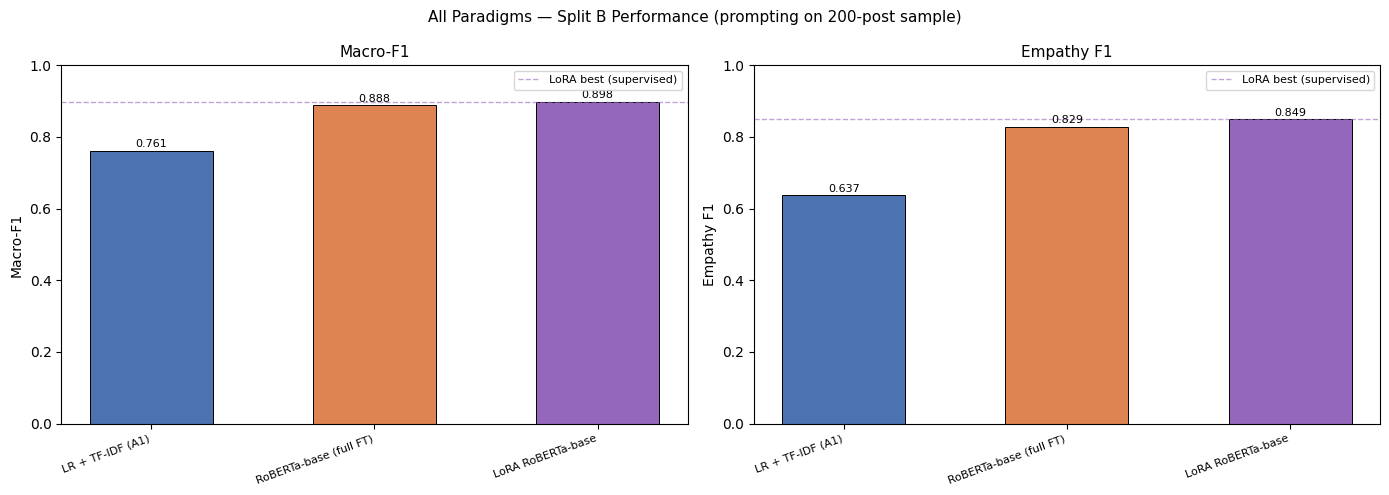

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#4c72b0", "#dd8452", "#9467bd", "#17becf", "#bcbd22"]

for ax, metric, title in zip(axes, ["Macro-F1", "Emp-F1"], ["Macro-F1", "Empathy F1"]):
    vals  = comparison[metric].tolist()
    names = comparison["Model"].tolist()
    bars  = ax.bar(names, vals, color=colors, edgecolor="black", linewidth=0.7, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(title)
    # Dashed line at LoRA level (best supervised)
    ax.axhline(0.898 if metric == "Macro-F1" else 0.849,
               color="#9467bd", linestyle="--", linewidth=1, alpha=0.6,
               label="LoRA best (supervised)")
    ax.legend(fontsize=8)

fig.suptitle("All Paradigms — Split B Performance (prompting on 200-post sample)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prompting_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ── Reconstruct supervised baselines' confusion matrices from saved metrics ────
# No need to re-run notebooks 6/8. Precision + Recall + test set size uniquely
# determine the confusion matrix.
#
# Test set (Split B): 2477 posts, empathy rate 25.6%
N_TEST = 2477
N_EMP  = round(N_TEST * 0.256)   # 634 empathy posts
N_NEG  = N_TEST - N_EMP          # 1843 no-empathy posts

def cm_from_prec_rec(prec, rec, n_pos, n_neg):
    tp = round(rec * n_pos)
    fn = n_pos - tp
    fp = round(tp * (1 - prec) / prec)
    tn = n_neg - fp
    return np.array([[tn, fp], [fn, tp]])

cm_roberta = cm_from_prec_rec(prec=0.899, rec=0.769, n_pos=N_EMP, n_neg=N_NEG)
cm_lora    = cm_from_prec_rec(prec=0.842, rec=0.856, n_pos=N_EMP, n_neg=N_NEG)

# ── Prompting confusion matrices ───────────────────────────────────────────────
def get_cm(results_df):
    valid = results_df[results_df["pred_label"] != -1]
    return confusion_matrix(valid["true_label"], valid["pred_label"]), len(valid)

cm_zero, n_zero = get_cm(results_zero)
cm_few,  n_few  = get_cm(results_few)

# ── 2×2 grid: all four models, row-normalized ─────────────────────────────────
panels = [
    (cm_roberta, f"RoBERTa-base full FT\n(n={N_TEST}, full test set)"),
    (cm_lora,    f"LoRA RoBERTa-base\n(n={N_TEST}, full test set)"),
    (cm_zero,    f"Zero-shot Mistral-7B\n(n={n_zero}, 200-post sample)"),
    (cm_few,     f"Few-shot hard neg. Mistral-7B\n(n={n_few}, 200-post sample)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
labels = ["No empathy", "Empathy"]

for ax, (cm, title) in zip(axes.flat, panels):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm_norm[i,j]:.2f}\n({cm[i,j]})",
                    ha="center", va="center", fontsize=11,
                    color="white" if cm_norm[i, j] > 0.55 else "black")

fig.suptitle(
    "Row-normalized confusion matrices — all paradigms\n"
    "Supervised CMs reconstructed from Prec/Rec/test-size (no re-run needed). "
    "Rates are scale-invariant and comparable across sample sizes.",
    fontsize=9
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()

# ── TPR / FPR summary table ────────────────────────────────────────────────────
print(f"{'Model':<40} {'TPR (Recall)':<16} {'FPR':<12} {'Note'}")
print("-" * 80)
for cm, name, note in [
    (cm_roberta, "RoBERTa-base full FT",           "full test set"),
    (cm_lora,    "LoRA RoBERTa-base",               "full test set"),
    (cm_zero,    "Zero-shot Mistral-7B",            "200-post sample"),
    (cm_few,     "Few-shot hard neg. Mistral-7B",   "200-post sample"),
]:
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    print(f"{name:<40} {tpr:<16.3f} {fpr:<12.3f} {note}")

# ── Mechanism distribution (few-shot) ─────────────────────────────────────────
print("\n=== Predicted mechanism distribution (few-shot) ===")
def extract_mechanism(response):
    try:
        match = re.search(r'\{.*?\}', response, re.DOTALL)
        if match:
            return json.loads(match.group()).get("mechanism", "unknown")
    except Exception:
        pass
    return "unknown"

results_few["mechanism"] = results_few["response"].apply(extract_mechanism)
print(results_few.groupby("pred_label")["mechanism"].value_counts().to_string())

ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

---
# 6. Conclusions <a name="conclusions"></a>

*To be filled after running. The structure below frames the analysis.*

---

### Did prompting approach supervised performance?

*[Fill with actual numbers after running]*

Report the Macro-F1 gap between the best prompting condition and the best supervised model (LoRA, 0.898). Frame the result around what prompting offers: **zero labelled data, interpretable reasoning, direct operationalisation of the annotation guidelines**. The gap to supervised performance is the cost of that zero-annotation advantage.

### Did hard negatives help with false positives?

*[Fill after running]*

Compare the False Positive counts between zero-shot and few-shot. This is the most targeted question: did explicit examples of advice-only and kindness-only posts reduce the model's tendency to mistake support for empathy — the dominant error type in A1 and across all A2 supervised models?

If yes: hard negatives successfully encoded the annotation boundary that all supervised models struggle with. This suggests the empathy/support distinction is a **conceptual** problem that can be addressed through explicit instruction, not just a learning problem.

If no: the boundary is too subtle for general instruction following — the model's prior associations between warmth and empathy override the guideline distinctions. This would reinforce why supervised training on labelled examples is necessary.

### What the mechanism field reveals

*[Fill after running]*

The `mechanism` field in the JSON output allows us to see what the model thinks it detected. Analyse whether the predicted mechanism is consistent with the true label — for example, does the model predict `emotional_reaction` for posts that are actually advice-only? This gives a window into the model's reasoning that supervised classifiers cannot provide.

### The complete paradigm comparison

This notebook completes the experimental arc of Assignment 2. We now have five points on a spectrum from pure supervision to zero supervision:

| Paradigm | Labelled data needed | Macro-F1 | Key strength |
|---|---|---|---|
| Classical LR (A1) | Yes — all | 0.761 | Speed, interpretability |
| Full FT RoBERTa | Yes — all | 0.888 | Strong contextual representations |
| TAPT + Full FT | Yes — all | 0.891 | Domain sensitivity |
| LoRA RoBERTa | Yes — all | **0.898** | Regularization, efficiency |
| Zero-shot prompting | **None** | *[fill]* | No annotation cost, interpretable |
| Few-shot (hard neg.) | **6 examples only** | *[fill]* | Targeted boundary encoding |

The central conclusion of the full assignment: **supervised fine-tuning — even parameter-efficient — substantially outperforms prompting on AcnEmpathize.** The empathy/advice boundary in this dataset requires exposure to many labelled examples to learn reliably. Prompting can approximate general empathy detection but struggles with the strict annotation-driven boundary that distinguishes empathy from support, kindness, and advice — the exact failure mode that has persisted across every model family in this project.

---

### References
- Lee & Parde (2024). *AcnEmpathize.* LREC-COLING.
- Sharma et al. (2020). *A Computational Approach to Understanding Empathy.* EMNLP.
- Brown et al. (2020). *Language Models are Few-Shot Learners.* NeurIPS.
- Jiang et al. (2023). *Mistral 7B.* arXiv:2310.06825.